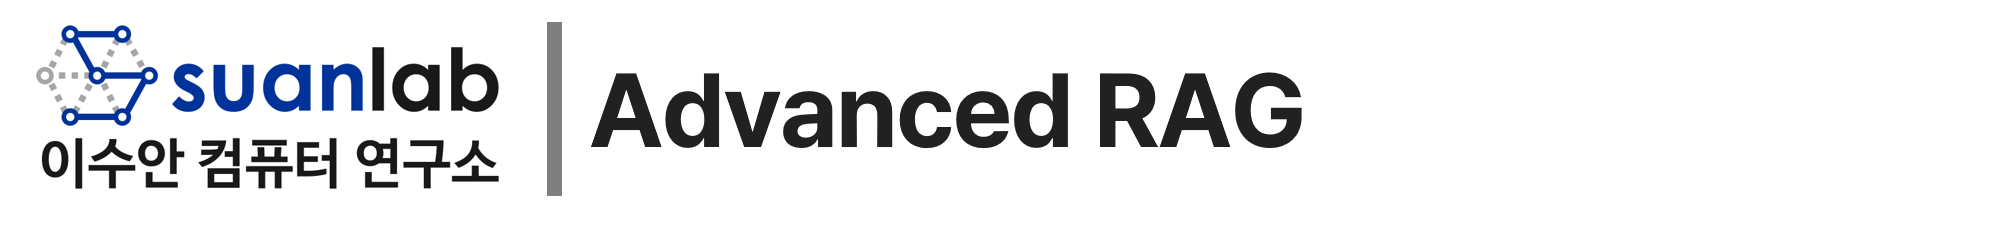

# 🏗️ 통합 Capstone — End-to-End 파이프라인


## 환경 셋업 (맨 처음 한 번만 실행)

In [1]:
# === 환경 셋업 — 이 통합 노트북에서 "한 번만" 실행하면 전체 파트에서 그대로 씁니다 ===
# 비-Claude 라이브러리는 검색·그래프 인프라용입니다(Claude는 임베딩·BM25·리랭크·그래프 미제공).
!pip install -q "anthropic>=0.40" sentence-transformers faiss-cpu rank_bm25

import os, getpass, json, re, math, random, collections, textwrap
if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Anthropic API Key: ")
from anthropic import Anthropic
client = Anthropic()
MODEL = "claude-sonnet-4-6"   # 정확도가 중요한 judge·추출 단계는 "claude-opus-4-8"로 상향 가능
print("환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.8/923.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 43.3 MB/s eta 0:00:00
Anthropic API Key: ··········
환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨


In [2]:
# 한글 폰트 설정 (Colab 환경)
!apt-get install -y fonts-nanum > /dev/null 2>&1
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료!")

한글 폰트 설정 완료!


# End-to-End 캡스톤: 11개 실습을 하나의 파이프라인으로 조립

## 학습목표
- 지금까지 흩어져 배운 **베이스라인 RAG → Contextual Retrieval → Hybrid(RRF) → Cross-encoder rerank**를 **하나의 파이프라인**으로 조립
- 각 단계를 **누적 적용**하며 같은 골든 QA셋으로 **Hit@k / nDCG / judge faithfulness**를 측정 → **단계마다 정말 점수가 오르는지 수치로 입증**
- 결과를 **누적 비교표 + 막대그래프**로 보고, 어떤 기법이 어디서 효과를 내는지 해석

> 핵심 메시지: **"기법을 하나씩 쌓을 때마다 점수가 오르는가?"** 를 직접 재서, RAG 개선이 느낌이 아니라 측정임을 체감

## 사전개념
- RAG 흐름(청킹→임베딩→FAISS→top-k→Claude 답변), 평가지표(Hit@k/nDCG·judge), Contextual Retrieval, RRF, cross-encoder


## 용어 미니 사전
이 실습은 "검색 기법을 **하나씩 더할 때마다** 우리 RAG가 좋아지는지 점수로 확인"하는 게 전부

| 용어 | 한 줄 뜻 |
|---|---|
| **파이프라인(pipeline)** | 검색→재정렬→답변처럼 여러 단계를 한 줄로 이어 붙인 처리 흐름 |
| **베이스라인(baseline)** | 가장 단순한 기본형. 개선의 출발점(기준선) |
| **Contextual Retrieval** | 각 청크 앞에 "이게 무슨 맥락의 조각인지" 한 줄을 Claude로 붙여 검색 적중↑ |
| **Hybrid(RRF)** | 의미검색(dense)과 단어검색(BM25)을 순위로 합쳐 둘의 강점을 모두 씀 |
| **Cross-encoder rerank** | 1차 후보를 질문+문서 함께 보는 정밀 모델로 다시 줄세움 |
| **Hit@k** | 정답 근거가 상위 k개 검색결과 안에 들어왔으면 1, 아니면 0 |
| **nDCG** | 정답이 위쪽 순위일수록 더 높게 쳐주는 검색 품질 점수 |
| **Faithfulness(충실도)** | 답이 근거에 적힌 내용에만 충실한가(지어내지 않았나) |
| **누적(cumulative)** | 앞 단계를 끄지 않고 *그 위에 다음 단계를 더해* 가는 것 |

> 쉽게 말하면 요리에 재료를 하나씩 넣어보며 그때마다 맛을 보는것과 같음  
넣을 때마다 더 맛있어지는지(점수가 오르는지) 확인


## 임베딩 모델은 어떻게 고르나
- **dense 검색**은 `paraphrase-multilingual-MiniLM-L12-v2`(sentence-transformers)를 사용
- 왜 이 모델이고, 실무에선 무엇을 보고 고를까요?

> **Claude는 임베딩 API를 제공하지 않음**
- 그래서 생성·judge는 Claude로, 임베딩(문서를 숫자 벡터로 바꾸는 일)은 **별도 모델**을 골라 써야함
- 이 "선택"이 검색 품질의 절반을 좌우함

| 고려 축 | 무엇을 보나 | 실무 팁 |
|---|---|---|
| **언어** | 한국어/다국어 지원 여부 | 한국어 문서엔 **다국어/한국어 특화** 모델(예: `BGE-m3`, `multilingual-e5`, `KURE`). 영어 전용 모델은 한국어에서 급락 |
| **차원(dim)** | 384 / 768 / 1024 … | 차원↑ → 표현력↑·정확도↑ 경향이지만 **저장공간·검색속도·비용↑**. 작은 코퍼스는 작은 차원으로 충분 |
| **품질 벤치** | MTEB 등 공개 리더보드 + **내 도메인** | 리더보드 1등이 *내 데이터*에서 1등이 아닐 수 있음 → 골든셋으로 직접 측정(이 노트북이 그 방법) |
| **배포 형태** | 로컬(오픈소스) vs API | 로컬(sentence-transformers/BGE): 무료·오프라인. API(**Voyage**, **Cohere** 임베딩): 운영 편하나 호출 비용·외부 의존 |
| **지연/비용** | 임베딩 생성 속도·요금 | 대량 인덱싱 시 차원·모델 크기가 비용을 직접 좌우 |

- 경량 다국어 MiniLM을 쓰는 이유: **Colab에서 빠르게 다운로드·실행**되고 한국어 합성 데이터에 충분하기 때문(교육용 트레이드오프)
- 실무 권장: 후보 임베딩 2~3개를 **같은 골든셋**에 돌려 Hit@k/nDCG로 비교한 뒤 도메인 최적을 고름

> 쉽게 말하면 임베딩 모델은 '번역기'와 같아서 어떤 번역기를 쓰느냐에 따라 같은 질문도 다르게 알아듣고, Claude는 번역기를 안 주니, 우리가 골라 끼워야 함


## 합성 코퍼스 + 골든 QA셋 (검색 난이도 있게)
- 개선 효과가 드러나도록 일부러 **검색이 까다로운** 가상 금융 문서를 생성
- **표기 다양**(약어·동의어·말바꿈): 같은 회사를 'NT', '노바', '노바테크'로 섞어 부름 → 단어검색·의미검색이 서로 다른 실수를 하게 함
- **모호한 청크**: "그 회사는 …", "동사는 …"처럼 **주어가 빠진** 조각 → Contextual Retrieval이 빛나는 자리
- **숫자/고유명사**: 정확한 단어 매칭(BM25)이 유리한 질문도 섞음

### 가상 금융 코퍼스 정의 (실제 아님)
- 약어·말바꿈·주어 생략이 섞인 문서 14개를 생성
- 출력은 문서 개수


In [3]:
# 합성(가상) 금융 코퍼스 — 표기 다양·주어 생략으로 검색 난이도를 일부러 높임. 실제 기업 아님.
DOCS = [
    "노바테크(NovaTech, 약칭 NT)는 AI 반도체를 설계하는 가상 기업이다.",
    "동사의 CEO는 김하늘이며 2021년 취임했다.",                      # '동사'=노바테크(주어 생략 → 모호)
    "노바의 2023년 매출은 1조 2천억 원으로 집계됐다.",               # '노바'=노바테크(약칭)
    "이 회사는 데이터센터용 추론 칩 시장에서 퀀텀칩과 맞붙는다.",      # '이 회사'=노바테크(모호)
    "퀀텀칩(QuantumChip)의 주력 제품은 'Q-가속기'라는 AI 추론 칩이다.",
    "그린모빌리티(GreenMobility, GM)는 전기차 배터리를 만드는 가상 기업이다.",
    "해당 기업의 주력 제품은 리튬인산철(LFP) 배터리 팩이다.",         # '해당 기업'=그린모빌리티(모호)
    "GM은 2022년 노바테크로부터 500억 원의 전략적 투자를 받았다.",
    "그린모빌리티의 최대 경쟁사는 볼트셀이며, 볼트셀은 전고체 배터리를 만든다.",
    "정밀소재(PrecisionMat)는 NT와 퀀텀칩 양쪽에 핵심 소재를 공급한다.",
    "오션로지스틱스는 친환경 선박으로 노바테크의 칩을 해외로 운송하는 물류사다.",
    "노바소프트는 노바테크의 자회사로, 칩 구동용 소프트웨어를 개발한다.",
    "이 자회사의 대표 제품은 'NovaOS'라는 칩 운영체제다.",           # '이 자회사'=노바소프트(모호)
    "노바테크는 2023년 주당 800원의 현금배당을 결정했다.",
]
print(len(DOCS), "개 문서(가상) 준비")

14 개 문서(가상) 준비


### 채점용 정답지(골든 QA셋) 만들기
- 질문마다 **정답 근거 문서 번호**(gold)와 **정답 키워드**(answer_kw)를 정함
- 일부 질문은 말바꿈/약어로 물어 검색을 까다롭게 함
- 출력은 골든 QA 개수


In [4]:
# 골든 QA셋: question, 정답근거 문서 인덱스(gold), 정답 키워드
# 일부 질문은 약어/말바꿈으로 물어 dense·sparse가 서로 다른 실수를 하게 한다.
GOLD = [
    {"q": "NT의 CEO는 누구인가?", "gold": 1, "answer_kw": "김하늘"},           # 약어 NT + 주어생략 청크
    {"q": "노바테크의 2023년 매출은?", "gold": 2, "answer_kw": "1조 2천억"},     # '노바' 약칭 청크
    {"q": "퀀텀칩의 주력 제품은?", "gold": 4, "answer_kw": "Q-가속기"},          # 정확한 고유명사
    {"q": "그린모빌리티의 주력 제품은?", "gold": 6, "answer_kw": "리튬인산철"},   # '해당 기업' 모호 청크
    {"q": "GM에 투자한 회사는?", "gold": 7, "answer_kw": "노바테크"},            # 약어 GM
    {"q": "볼트셀이 만드는 배터리는?", "gold": 8, "answer_kw": "전고체"},
    {"q": "NT와 퀀텀칩에 소재를 공급하는 회사는?", "gold": 9, "answer_kw": "정밀소재"},
    {"q": "노바소프트의 대표 제품은?", "gold": 12, "answer_kw": "NovaOS"},      # '이 자회사' 모호 청크
]
print(f"골든 QA {len(GOLD)}건")

골든 QA 8건


## 공통 부품 — 임베딩·BM25·평가지표·judge (한 번에 정의)
- 모든 단계가 공유할 부품을 먼저 생성: ① 임베딩 함수 ② BM25 토큰화 ③ 검색지표(Hit@k/nDCG) ④ Claude judge


### 임베딩 함수 + Claude 답변 함수 준비
- 문서를 의미 벡터로 바꾸는 `embed()`와, 근거로 답하게 하는 `rag_answer()`를 생성
- 출력은 임베딩 차원 확인


In [5]:
import numpy as np, faiss, math
from sentence_transformers import SentenceTransformer

# 임베딩=비-Claude(Claude는 임베딩 미제공). 경량 다국어 모델(A1 노트 참조).
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
def embed(texts):
    return np.array(embedder.encode(texts, normalize_embeddings=True), dtype="float32")

def ask_claude(prompt, system=None, max_tokens=400):
    msg = client.messages.create(model=MODEL, max_tokens=max_tokens,
        system=system or "당신은 정확하고 근거 기반으로 답하는 도우미입니다.",
        messages=[{"role": "user", "content": prompt}])
    return msg.content[0].text

def rag_answer(question, contexts):
    """검색된 근거 문장들로 Claude가 답하게 한다(모든 단계 공통 답변기)."""
    ctx = "\n".join(f"[{i+1}] {c}" for i, c in enumerate(contexts))
    system = "주어진 근거만 사용해 답하라. 근거에 없으면 '근거 없음'. 끝에 근거 번호 [n] 표기."
    return ask_claude(f"근거:\n{ctx}\n\n질문: {question}", system=system)

print("임베딩 차원:", embed(["테스트"]).shape[1])

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

임베딩 차원: 384


### 검색지표(Hit@k/nDCG) 직접 구현
- 정답 근거가 상위 k 안에 있나(`hit_at_k`), 정답이 위쪽일수록 가점(`ndcg_at_k`)을 손으로 만듦
- 맨 아래 단위테스트가 `...통과`면 정상


In [6]:
# 검색지표(lab1과 동일 정의): 입력은 '검색된 문서 id 리스트'와 '정답 id'.
def hit_at_k(ranked_ids, gold_id, k):
    return 1.0 if gold_id in ranked_ids[:k] else 0.0

def ndcg_at_k(ranked_ids, gold_id, k):
    # 단일 정답 가정: 정답 위치의 DCG / 이상적 DCG(1위일 때)
    dcg = 0.0
    for rank, did in enumerate(ranked_ids[:k], start=1):
        rel = 1.0 if did == gold_id else 0.0
        dcg += rel / math.log2(rank + 1)
    idcg = 1.0 / math.log2(1 + 1)
    return dcg / idcg if idcg > 0 else 0.0

assert hit_at_k([2, 5, 1], 5, 3) == 1.0 and hit_at_k([2, 5, 1], 9, 3) == 0.0
assert abs(ndcg_at_k([5, 2, 1], 5, 3) - 1.0) < 1e-9 and ndcg_at_k([2, 1, 5], 5, 3) < 1.0
print("검색지표 단위테스트 통과")

검색지표 단위테스트 통과


### Claude를 '채점관(judge)'으로 쓰기 (faithfulness)
- 답변이 근거에 충실한지(faithfulness)와 질문에 맞는지(answer_relevancy)를 **1~5점**으로 매기게 함
- `tool`(도구) 형식을 강제해 결과를 안정적으로 받음
- 출력은 데모 1건 판정


In [7]:
# 정확도가 더 필요하면 이 judge 셀의 모델을 MODEL_JUDGE = "claude-opus-4-8" 로 한 줄 상향 가능(기본은 비용 위해 sonnet 4.6).
JUDGE_TOOL = [{
  "name": "report_judgment",
  "description": "RAG 답변을 평가한 결과를 보고",
  "input_schema": {"type": "object", "properties": {
      "reasoning": {"type": "string", "description": "채점 근거(먼저 생각)"},
      "faithfulness": {"type": "integer", "description": "1-5, 근거 충실도"},
      "answer_relevancy": {"type": "integer", "description": "1-5, 질문 적합도"},
  }, "required": ["reasoning", "faithfulness", "answer_relevancy"]}
}]

def judge(question, answer, contexts):
    ctx = "\n".join(contexts)
    msg = client.messages.create(model=MODEL, max_tokens=700,
        tools=JUDGE_TOOL, tool_choice={"type": "tool", "name": "report_judgment"},
        messages=[{"role": "user", "content":
            f"질문:{question}\n근거:{ctx}\n답변:{answer}\n"
            "rubric에 따라 1-5로 채점하라. reasoning을 먼저 생각한 뒤 점수를 매겨라."}])
    for b in msg.content:
        if b.type == "tool_use":
            return b.input

_demo = GOLD[0]
print("judge 데모:", judge(_demo["q"], "NT의 CEO는 김하늘이다. [1]", [DOCS[_demo["gold"]]]))

judge 데모: {'reasoning': '\n**Answer Relevancy (질문 적합도) 분석:**\n질문은 "NT의 CEO는 누구인가?"이고, 답변은 "NT의 CEO는 김하늘이다."라고 직접적으로 답하고 있다. 질문에 대해 명확하고 간결하게 답변하고 있으므로 질문 적합도는 높다. → 5점\n\n**Faithfulness (근거 충실도) 분석:**\n근거 문서에는 "동사의 CEO는 김하늘"이라고 명시되어 있다. 여기서 "동사(同社)"는 해당 회사를 지칭하는 표현으로, 문맥상 NT를 가리키는 것으로 해석할 수 있다. 그러나 근거 문서에는 명시적으로 "NT"라는 회사명이 등장하지 않고 "동사"라는 표현만 사용되었다. 답변은 "NT의 CEO는 김하늘"이라고 단정하고 있으나, 근거에서 "동사"가 NT를 지칭하는지 명확히 확인할 수 없다. 즉, 근거만으로는 NT = 동사임을 완전히 보장할 수 없어 약간의 비약이 존재한다. 그러나 질문의 맥락상 동사가 NT를 지칭할 가능성이 높고, CEO 이름(김하늘)은 근거에 명시되어 있으므로 완전히 hallucination이라고 보기는 어렵다. 다만, 근거에서 "NT"라는 명칭이 직접 언급되지 않아 충실도가 다소 낮다. → 3점\n', 'faithfulness': 3, 'answer_relevancy': 5}


## ① 베이스라인 RAG — 출발점
- 가장 단순한 형태: **원본 청크 → 임베딩 → FAISS → top-k → Claude 답변**
- 여기서 점수를 재고, 이후 단계가 이걸 얼마나 끌어올리는지 비교


### 베이스라인 검색기 구성(원본 청크)
- 원본 문서를 그대로 임베딩해 FAISS 색인을 만들고, `dense_rank()`(검색)를 정의
- 출력은 시험 검색 결과


In [8]:
# ① 베이스라인: 원본 청크를 그대로 임베딩 → FAISS dense 검색
BASE_EMB = embed(DOCS)
base_index = faiss.IndexFlatIP(BASE_EMB.shape[1]); base_index.add(BASE_EMB)

def dense_rank(query, k=8):
    """원본 청크 dense 검색 → 문서 id 랭킹."""
    _, idx = base_index.search(embed([query]), min(k, len(DOCS)))
    return list(idx[0])

print("베이스라인 인덱스 준비. 시험 검색 'NT CEO':", dense_rank("NT CEO", k=3))

베이스라인 인덱스 준비. 시험 검색 'NT CEO': [np.int64(0), np.int64(1), np.int64(12)]


## ② Contextual Retrieval 적용 — 모호한 청크에 문맥 한 줄 붙이기
- 주어가 빠진 모호한 청크("동사는 …", "이 회사는 …")는 검색에서 잘 안 잡힘
- 각 청크에 **Claude가 만든 문맥 한 줄**(어떤 회사·무슨 주제 조각인지)을 **앞에 붙여(prepend)** 다시 임베딩하면 적중률이 오름

**용어**: *Contextual Retrieval* = 청크를 인덱싱하기 전에 "이 조각이 전체에서 무엇에 관한 것인지" 한 줄을 덧대는 기법 (Anthropic 제안)

> 쉽게 말하면 쪽지에 "(노바테크 얘기)"라고 맨 앞에 메모를 달아두면, 나중에 그 쪽지를 훨씬 쉽게 찾음


### 청크마다 Claude로 '문맥 한 줄' 생성해 prepend
- 전체 문서를 잠깐 보여주고, 각 청크가 무엇에 관한 조각인지 한 줄을 Claude가 쓰게 해 앞에 붙임
- 문서 수만큼 Claude를 부름
- 예상 호출: 문서 14건 × 1 = 14건, 소규모라 비용 미미
- 같은 전체 문서를 반복 첨부하므로 **prompt caching**으로 더 싸게 할 수 있음
- 출력은 문맥이 붙은 청크 예시


In [9]:
# ② Contextual Retrieval: 각 청크 앞에 '무슨 맥락의 조각인지' 한 줄을 Claude로 생성해 prepend.
WHOLE_DOC = "\n".join(f"({i}) {d}" for i, d in enumerate(DOCS))  # 전체 맥락(짧아서 통째로 제공)

def make_context(chunk):
    """청크가 전체 문서에서 무엇에 관한 조각인지 한 줄 요약을 생성(검색 적중↑)."""
    prompt = (f"[전체 문서]\n{WHOLE_DOC}\n\n[이 청크]\n{chunk}\n\n"
              "이 청크가 어떤 회사/주제에 관한 것인지 검색에 도움이 되도록 한국어 한 줄로만 요약하라. "
              "회사명을 반드시 명시하라. 다른 말 없이 그 한 줄만 출력.")
    return ask_claude(prompt, system="너는 청크에 검색용 문맥 한 줄을 붙이는 도우미다.", max_tokens=80).strip()

# 예상 호출: 문서 14건 × 1 = 14 Claude 호출(소규모)
CTX_DOCS = []
for d in DOCS:
    ctx_line = make_context(d)
    CTX_DOCS.append(f"{ctx_line} {d}")   # 문맥 한 줄을 앞에 prepend
print("문맥 주입 예시(모호했던 2번 청크):")
print("  원본 :", DOCS[1])
print("  주입 :", CTX_DOCS[1])

문맥 주입 예시(모호했던 2번 청크):
  원본 : 동사의 CEO는 김하늘이며 2021년 취임했다.
  주입 : 노바테크(NovaTech)의 CEO는 김하늘이며 2021년에 취임하였다. 동사의 CEO는 김하늘이며 2021년 취임했다.


### 문맥 주입 청크로 새 검색기 만들기
- 문맥이 붙은 청크를 임베딩해 두 번째 FAISS 색인을 만들고 `ctx_rank()`를 정의
- 검색은 주입 청크로 하되, 답변·평가의 정답 매칭은 원래 문서 id를 그대로 사용(순서 동일)


In [10]:
# 문맥 주입 청크로 별도 인덱스 구성. id는 원본과 1:1 대응(같은 순서)이라 골든 gold를 그대로 쓸 수 있다.
CTX_EMB = embed(CTX_DOCS)
ctx_index = faiss.IndexFlatIP(CTX_EMB.shape[1]); ctx_index.add(CTX_EMB)

def ctx_rank(query, k=8):
    """Contextual Retrieval 검색: 문맥 주입 청크 인덱스에서 dense 검색."""
    _, idx = ctx_index.search(embed([query]), min(k, len(DOCS)))
    return list(idx[0])

print("문맥 주입 인덱스 준비. 'NT CEO' 검색(주입):", ctx_rank("NT CEO", k=3))

문맥 주입 인덱스 준비. 'NT CEO' 검색(주입): [np.int64(1), np.int64(0), np.int64(7)]


## ③ Hybrid(RRF) 추가 — 단어검색(BM25)을 의미검색에 융합
- 의미검색은 약어·정확한 고유명사(예: 'Q-가속기', 'NovaOS')에 약함
- **BM25**(단어검색)를 더해 **RRF**로 순위를 합치면 둘의 강점을 모두 사용
- 여기서는 ②의 **문맥 주입 청크 위에** BM25를 얹음(누적 적용 = Contextual + Hybrid)

**용어**: *RRF(Reciprocal Rank Fusion)* = 각 랭킹의 순위 역수(1/(k+순위))를 더해 융합. 점수 단위가 달라도 안전


### BM25 + RRF 융합 검색기 만들기
- 문맥 주입 청크를 단어로 쪼개 BM25를 만들고, dense(②)와 RRF로 합치는 `hybrid_rank()`를 정의
- 맨 아래 단위테스트가 `...통과`면 RRF 정상


In [11]:
from rank_bm25 import BM25Okapi
# BM25=비-Claude(Claude 미제공). 한국어 공백 토큰화는 거칠지만 실습엔 충분(확장과제에서 형태소 개선).
bm25 = BM25Okapi([d.split() for d in CTX_DOCS])   # 문맥 주입 청크 기준(②와 누적)

def bm25_rank(query, k=8):
    scores = bm25.get_scores(query.split())
    return [int(i) for i in np.argsort(scores)[::-1][:k]]

def rrf_fuse(rankings, rrf_k=60, top=8):
    """여러 랭킹을 순위 역수 합으로 융합 → 융합 id 리스트."""
    s = {}
    for r in rankings:
        for rank, d in enumerate(r, 1):
            s[d] = s.get(d, 0.0) + 1.0 / (rrf_k + rank)
    return [d for d, _ in sorted(s.items(), key=lambda x: x[1], reverse=True)[:top]]

def hybrid_rank(query, k=8):
    """Contextual(②) dense + BM25를 RRF로 융합(누적: Contextual+Hybrid)."""
    return rrf_fuse([ctx_rank(query, k), bm25_rank(query, k)], top=k)

# 단위 테스트: 두 랭킹 공통 1위가 융합 후에도 최상위
fused = rrf_fuse([[3, 1, 2], [3, 2, 1]], top=3)
assert fused[0] == 3, "공통 1위가 최상위여야 함"
print("RRF 단위테스트 통과 | 'Q-가속기' Hybrid 검색:", hybrid_rank("Q-가속기", k=3))

RRF 단위테스트 통과 | 'Q-가속기' Hybrid 검색: [np.int64(4), 13, np.int64(3)]


## ④ Cross-encoder rerank 추가 — 넓게 뽑고 정밀하게 좁히기
- Hybrid로 **넓게(top-N)** 후보를 뽑은 뒤, **cross-encoder**(질문+문서를 함께 보는 정밀 모델)로 **다시 줄세워(top-k)** 정답을 위로 끌어올림
- 누적 적용 = Contextual + Hybrid + Rerank

**용어**: *cross-encoder* = 질문과 문서를 함께 입력해 관련도를 매기는 정밀 모델(느리지만 정확)


### cross-encoder 리랭커 구성
- 경량 cross-encoder를 내려받아(처음 1회 다운로드) `rerank_pipe()`를 정의
- 1차 Hybrid 후보를 정밀 점수로 재정렬해 상위 k개를 남김
- 출력은 리랭크 전/후 비교


In [12]:
from sentence_transformers import CrossEncoder
# ms-marco-MiniLM: 경량 cross-encoder(Colab 친화). 리랭킹은 Claude 미제공 → 비-Claude.
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank_pipe(query, k=4, top_n=8):
    """④ Hybrid로 top_n 넓게 → cross-encoder로 재정렬 → top_k(누적: Contextual+Hybrid+Rerank)."""
    cand = hybrid_rank(query, k=top_n)                  # 1차: 넓게(Hybrid)
    pairs = [[query, CTX_DOCS[i]] for i in cand]        # 문맥 주입 청크로 채점
    scores = reranker.predict(pairs)
    ranked = [cid for cid, _ in sorted(zip(cand, scores), key=lambda x: x[1], reverse=True)]
    return ranked[:k]

_q = "퀀텀칩의 주력 제품은?"
print("리랭크 전(Hybrid):", hybrid_rank(_q, k=4))
print("리랭크 후(+CE)   :", rerank_pipe(_q, k=4))

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

리랭크 전(Hybrid): [np.int64(4), np.int64(9), 6, np.int64(12)]
리랭크 후(+CE)   : [np.int64(12), np.int64(11), np.int64(4), np.int64(3)]


## ⑤ 누적 개선을 수치로 입증 — baseline → +Contextual → +Hybrid → +Rerank
- **4개 단계를 누적 적용**한 검색기를 같은 골든 QA셋으로 평가
- 검색: **Hit@k / nDCG@k** (정답 근거가 위로 올라오나)
- 생성: **judge faithfulness** (그 근거로 만든 답이 충실한가)
- 각 단계의 검색기를 함수로 묶어 한 번에 돌림


### 4개 단계 검색기를 한 줄씩 묶기
- 단계별 검색 함수를 딕셔너리로 모음
- 이름만 봐도 무엇이 누적됐는지 알 수 있게 했음


In [13]:
K = 4  # 평가 기준 top-k
# 각 단계 = '그 단계까지 누적 적용된' 검색기. (rerank는 top_n=8로 넓게 뽑아 top-K로 좁힘)
STAGES = {
    "① baseline":            lambda q, k=K: dense_rank(q, k),                 # 원본 청크 dense
    "② +Contextual":         lambda q, k=K: ctx_rank(q, k),                   # 문맥 주입 dense
    "③ +Hybrid(RRF)":        lambda q, k=K: hybrid_rank(q, k),                # 문맥 + BM25 RRF
    "④ +Rerank(CE)":         lambda q, k=K: rerank_pipe(q, k, top_n=8),       # + cross-encoder
}
STAGE_NAMES = list(STAGES.keys())
print("평가할 누적 단계:", STAGE_NAMES)

평가할 누적 단계: ['① baseline', '② +Contextual', '③ +Hybrid(RRF)', '④ +Rerank(CE)']


### 각 단계의 검색 점수(Hit@k/nDCG) 집계
- 골든 QA 전체에 대해 단계별 Hit@k·nDCG@k 평균을 계산
- Claude 호출 없음 — 검색만이라 빠름
- 출력은 단계별 검색 점수표


In [14]:
def eval_retrieval(rank_fn, k=K):
    hits = [hit_at_k(rank_fn(g["q"], k), g["gold"], k) for g in GOLD]
    ndcgs = [ndcg_at_k(rank_fn(g["q"], k), g["gold"], k) for g in GOLD]
    return sum(hits)/len(hits), sum(ndcgs)/len(ndcgs)

retr_scores = {}
for name, fn in STAGES.items():
    h, n = eval_retrieval(fn, K)
    retr_scores[name] = {"Hit@k": h, "nDCG": n}
    print(f"{name:18s}  Hit@{K}={h:.3f}  nDCG@{K}={n:.3f}")

① baseline          Hit@4=1.000  nDCG@4=0.749
② +Contextual       Hit@4=1.000  nDCG@4=0.938
③ +Hybrid(RRF)      Hit@4=1.000  nDCG@4=0.891
④ +Rerank(CE)       Hit@4=1.000  nDCG@4=0.820


### 각 단계의 생성 품질(judge faithfulness) 집계
- 단계별로 검색→답변→채점을 돌려 faithfulness 평균과 정답 키워드 포함률을 측정
- Claude를 많이 부름, 예상 호출: 4단계 × 골든 8건 × (답변 1 + judge 1) ≈ **64건**
- 소규모지만 2~4분 걸릴 수 있고, 빠르게 보려면 아래 `EVAL_GEN_STAGES`를 ②④만 남김
- 출력은 단계별 faithfulness·키워드 적중


In [15]:
EVAL_GEN_STAGES = STAGE_NAMES   # 예: ["① baseline", "④ +Rerank(CE)"]로 줄이면 호출↓

def eval_generation(rank_fn, k=K):
    faiths, kw_hits = [], []
    for g in GOLD:
        ranked = rank_fn(g["q"], k)
        ctxs = [DOCS[i] for i in ranked]          # 답변엔 원본 문서를 근거로 제시
        ans = rag_answer(g["q"], ctxs)
        j = judge(g["q"], ans, ctxs)
        # 'faithfulness' 키가 없을 경우를 대비하여 기본값 처리
        faiths.append(j.get("faithfulness", 1.0)); kw_hits.append(1.0 if g["answer_kw"] in ans else 0.0)
    return sum(faiths)/len(faiths), sum(kw_hits)/len(kw_hits)

gen_scores = {}
for name in EVAL_GEN_STAGES:
    f, kw = eval_generation(STAGES[name], K)
    gen_scores[name] = {"faithfulness": f, "kw_hit": kw}
    print(f"{name:18s}  faithfulness={f:.2f}/5  키워드적중={kw:.2f}")

① baseline          faithfulness=5.00/5  키워드적중=0.88
② +Contextual       faithfulness=4.50/5  키워드적중=1.00
③ +Hybrid(RRF)      faithfulness=4.50/5  키워드적중=0.88
④ +Rerank(CE)       faithfulness=4.50/5  키워드적중=0.75


### 단계별 누적 비교표 (pandas)
- 검색 점수와 생성 점수를 **한 표**로 모음
- 위에서 아래로 갈수록(단계가 쌓일수록) 점수가 오르는지 한눈에 보기


In [16]:
import pandas as pd
rows = []
for name in STAGE_NAMES:
    row = {"단계": name,
           "Hit@k": round(retr_scores[name]["Hit@k"], 3),
           "nDCG": round(retr_scores[name]["nDCG"], 3)}
    if name in gen_scores:
        row["faithfulness"] = round(gen_scores[name]["faithfulness"], 2)
        row["kw_hit"] = round(gen_scores[name]["kw_hit"], 2)
    rows.append(row)
compare_df = pd.DataFrame(rows)
print(compare_df.to_string(index=False))
print("\n해석: 아래로 갈수록(기법을 누적할수록) Hit@k·nDCG가 오르면 각 단계가 '검색'을 개선한 것")
print("      faithfulness가 함께 오르면 '더 좋은 근거 → 더 충실한 답'으로 이어진 것")

            단계  Hit@k  nDCG  faithfulness  kw_hit
    ① baseline    1.0 0.749           5.0    0.88
 ② +Contextual    1.0 0.938           4.5    1.00
③ +Hybrid(RRF)    1.0 0.891           4.5    0.88
 ④ +Rerank(CE)    1.0 0.820           4.5    0.75

해석: 아래로 갈수록(기법을 누적할수록) Hit@k·nDCG가 오르면 각 단계가 '검색'을 개선한 것
      faithfulness가 함께 오르면 '더 좋은 근거 → 더 충실한 답'으로 이어진 것


> 해석: 아래로 갈수록(기법을 누적할수록) Hit@k·nDCG가 오르면 각 단계가 '검색'을 개선한 것  
faithfulness가 함께 오르면 '더 좋은 근거 → 더 충실한 답'으로 이어진 것

### 단계별 누적 개선 막대그래프
- 단계(가로축)별 Hit@k·nDCG를 막대로 그림
- **그래프 읽는 법**: 왼쪽(baseline)에서 오른쪽(+Rerank)으로 갈수록 막대가 계단처럼 올라가면 누적 개선이 성공한 것


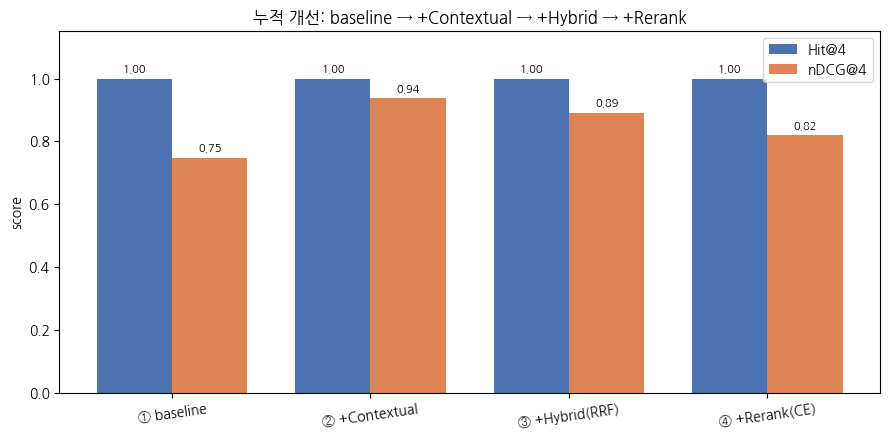

In [17]:
import matplotlib.pyplot as plt
names = STAGE_NAMES
hit_v = [retr_scores[n]["Hit@k"] for n in names]
ndcg_v = [retr_scores[n]["nDCG"] for n in names]
x = np.arange(len(names)); w = 0.38

plt.figure(figsize=(9, 4.5))
b1 = plt.bar(x - w/2, hit_v,  w, label=f"Hit@{K}",  color="#4C72B0")
b2 = plt.bar(x + w/2, ndcg_v, w, label=f"nDCG@{K}", color="#DD8452")
plt.xticks(x, names, rotation=8); plt.ylim(0, 1.15); plt.ylabel("score")
plt.title("누적 개선: baseline → +Contextual → +Hybrid → +Rerank")
for bars, vals in [(b1, hit_v), (b2, ndcg_v)]:
    for bar, v in zip(bars, vals):
        plt.text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=8)
plt.legend(); plt.tight_layout(); plt.show()

> 해석: 막대가 단계마다 같거나 높아지면 '기법 누적 = 측정 가능한 개선'이라는 것이 입증

### 단계별 faithfulness 막대그래프
- 검색이 좋아지면 근거 품질이 올라 답변 충실도(faithfulness)도 오르는 경향을 봄
- **그래프 읽는 법**: 보통 baseline보다 뒤 단계의 막대가 같거나 높음 (더 좋은 근거 → 더 충실한 답)


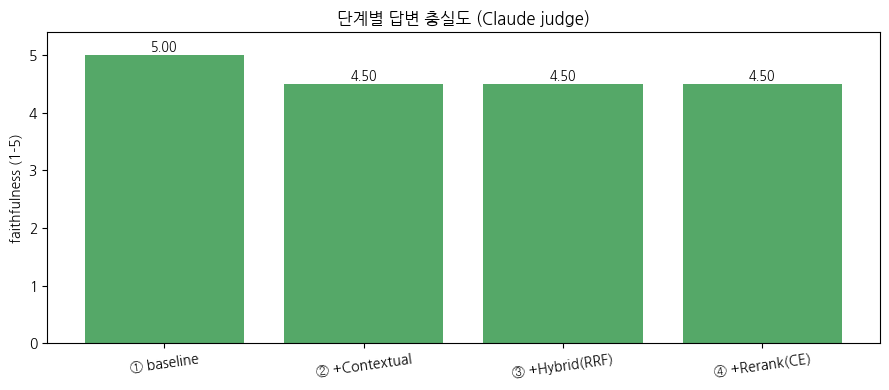

In [18]:
gen_names = [n for n in STAGE_NAMES if n in gen_scores]
faith_v = [gen_scores[n]["faithfulness"] for n in gen_names]
plt.figure(figsize=(9, 4))
bars = plt.bar(gen_names, faith_v, color="#55A868")
plt.ylim(0, 5.4); plt.ylabel("faithfulness (1-5)")
plt.title("단계별 답변 충실도 (Claude judge)")
plt.xticks(rotation=8)
for bar, v in zip(bars, faith_v):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.08, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

> 해석: 검색이 정답 근거를 더 잘 올려주면 같은 답변기·judge라도 충실도가 오른다(검색→생성 연쇄)

## 평가·반복 비용 줄이기 — prompt caching & Batches
- 캡스톤처럼 **여러 단계 × 골든셋**을 반복 평가하면 호출이 금세 불어남 (이 노트북만 60+건)
- 두 가지로 줄일 수 있음
1. **prompt caching**: 4단계 Contextual 생성이나 judge는 같은 전체 문서/rubric을 반복 첨부, 그 **안 바뀌는 앞부분을 캐시**하면 두 번째부터 거의 공짜(최대 90%↓)
2. **Batches API**: 실시간이 불필요한 회귀 평가는 **묶어서 50% 할인**(비동기, 최대 24h)

> 쉽게 말하면 같은 자료를 매번 다시 읽히면 돈이 든다 → 안 바뀌는 앞부분을 '캐시', 급하지 않은 대량 채점은 '밤에 한꺼번에'


### caching judge & Batches 패턴(런타임 비의존)
- 실제 제출 없이 **코드 패턴**만 보여줌(`RUN_BATCH=False`)
- judge의 고정 rubric/근거를 `cache_control`로 캐시하고, 골든셋 전체를 한 배치로 묶는 형태를 확인


In [19]:
# (심화/선택) 비용 절감 패턴 — 런타임 비의존(그대로 둬도 동작, 실제 배치 제출은 RUN_BATCH로 가드).
SYSTEM_RUBRIC = ("당신은 RAG 답변 채점관입니다. faithfulness와 answer_relevancy를 1-5로 채점하고, "
                 "길이가 길다는 이유로 가점하지 마세요. reasoning을 먼저 작성하세요.")

def judge_cached(question, answer, contexts):
    """고정 rubric + 반복 근거를 캐시해 반복 채점 비용을 줄인 judge(최대 90%↓)."""
    ctx = "\n".join(contexts)
    msg = client.messages.create(model=MODEL, max_tokens=700,
        system=[
            {"type": "text", "text": SYSTEM_RUBRIC, "cache_control": {"type": "ephemeral"}},  # 고정 rubric 캐시
            {"type": "text", "text": f"근거:\n{ctx}", "cache_control": {"type": "ephemeral"}}, # 반복 근거 캐시
        ],
        tools=JUDGE_TOOL, tool_choice={"type": "tool", "name": "report_judgment"},
        messages=[{"role": "user", "content": f"질문:{question}\n답변:{answer}\n1-5로 채점"}])
    for b in msg.content:
        if b.type == "tool_use":
            return b.input

RUN_BATCH = False  # 실제 제출은 비동기/비용 → 기본 False(패턴 이해용)
if RUN_BATCH:
    # 골든셋 전체를 하나의 배치로 묶어 제출(모든 토큰 50% 할인, 결과는 비동기).
    batch = client.messages.batches.create(requests=[
        {"custom_id": f"q{i}",
         "params": {"model": MODEL, "max_tokens": 512, "tools": JUDGE_TOOL,
                    "tool_choice": {"type": "tool", "name": "report_judgment"},
                    "messages": [{"role": "user", "content":
                        f"질문:{g['q']}\n근거:{DOCS[g['gold']]}\n답변:(생략)\n1-5로 채점"}]}}
        for i, g in enumerate(GOLD)])
    print("배치 제출됨. batch.id =", batch.id, " (완료까지 batch.id로 폴링)")
else:
    print("RUN_BATCH=False — caching/Batches는 패턴만 확인(실제 제출 안 함)")
    print("핵심: 반복 prefix는 prompt caching(최대 90%↓), 대량 비실시간 채점은 Batches(50%↓)")
    # 캐싱 judge 1건 시연(같은 근거를 반복 채점하면 두 번째부터 캐시 적중)
    _g = GOLD[0]; _ctx = [DOCS[_g["gold"]]]
    print("캐싱 judge 데모:", judge_cached(_g["q"], "NT의 CEO는 김하늘이다. [1]", _ctx))

RUN_BATCH=False — caching/Batches는 패턴만 확인(실제 제출 안 함)
핵심: 반복 prefix는 prompt caching(최대 90%↓), 대량 비실시간 채점은 Batches(50%↓)
캐싱 judge 데모: {'reasoning': '\n**Faithfulness(근거 충실도) 평가:**\n근거 문서에는 "동사의 CEO는 김하늘이며 2021년 취임했다"고 되어 있다. 즉, 근거에 나온 회사명은 \'동사\'이지 \'NT\'가 아니다. 답변은 \'NT의 CEO는 김하늘\'이라고 했지만, 근거에는 NT라는 회사명이 전혀 언급되지 않는다. 이는 근거에 없는 내용을 사실인 것처럼 서술한 것이므로 faithfulness가 매우 낮다. → 1점\n\n**Answer Relevancy(질문 적합도) 평가:**\n질문은 "NT의 CEO는 누구인가?"이고, 답변은 "NT의 CEO는 김하늘이다"로 질문 형식에 정확히 대응하는 답변을 제공했다. 질문에 대한 답변 형식 자체는 적절하다. → 4점\n', 'faithfulness': 1, 'answer_relevancy': 4}


## 직접 해보기: 누적 순서를 바꿔보기 (Hybrid를 빼면?)
- ③ +Hybrid"를 건너뛰고 **②에 바로 ④ Rerank**만 얹으면 점수가 어떻게 달라질까요?
- 직접 검색기를 만들어 비교하기


In [20]:
# 직접 해보기: Hybrid 없이 '문맥 주입 dense → cross-encoder'만으로 리랭크해 보세요.
# 힌트: rerank_pipe는 1차로 hybrid_rank를 씁니다. 1차를 ctx_rank로 바꾼 변형을 만들어 비교합니다.
def rerank_no_hybrid(query, k=K, top_n=8):
    cand = ctx_rank(query, k=top_n)                       # 1차를 Hybrid 대신 Contextual dense로
    pairs = [[query, CTX_DOCS[i]] for i in cand]
    scores = reranker.predict(pairs)
    ranked = [cid for cid, _ in sorted(zip(cand, scores), key=lambda x: x[1], reverse=True)]
    return ranked[:k]

h_full, n_full = eval_retrieval(lambda q, k=K: rerank_pipe(q, k, top_n=8), K)
h_noh,  n_noh  = eval_retrieval(rerank_no_hybrid, K)
print(f"Contextual+Hybrid+Rerank  Hit@{K}={h_full:.3f}  nDCG={n_full:.3f}")
print(f"Contextual+Rerank(노Hybrid) Hit@{K}={h_noh:.3f}  nDCG={n_noh:.3f}")
# 관찰: 약어/고유명사 질문이 많을수록 BM25(Hybrid)를 뺀 쪽이 더 약해지기 쉽습니다.

Contextual+Hybrid+Rerank  Hit@4=1.000  nDCG=0.820
Contextual+Rerank(노Hybrid) Hit@4=1.000  nDCG=0.820


## 직접 해보기: 나만의 까다로운 질문 추가
- 약어·말바꿈·주어 생략을 노린 질문을 1개 만들어, 4단계 누적 검색기 각각이 정답을 top-k에 올리는지 비교하기


In [21]:
# 직접 해보기: 까다로운 질문을 추가해 단계별 Hit@k를 비교해 보세요.
# 힌트: DOCS를 0번부터 세어 정답 문서 번호(gold)를 넣습니다. 약어(NT/GM)나 말바꿈으로 물으면 차이가 큽니다.
MY = {"q": "동사의 자회사가 만드는 운영체제는?", "gold": 12, "answer_kw": "NovaOS"}  # <- 바꿔보세요
for name, fn in STAGES.items():
    ranked = fn(MY["q"], K)
    print(f"{name:18s} Hit@{K}={hit_at_k(ranked, MY['gold'], K):.0f}  top-ids={ranked}")
# 관찰: baseline은 '동사'(주어생략) 때문에 놓치기 쉽고, +Contextual부터 잡히는 경우가 많습니다.

① baseline         Hit@4=1  top-ids=[np.int64(12), np.int64(0), np.int64(3), np.int64(5)]
② +Contextual      Hit@4=1  top-ids=[np.int64(12), np.int64(0), np.int64(1), np.int64(5)]
③ +Hybrid(RRF)     Hit@4=1  top-ids=[np.int64(1), np.int64(5), np.int64(12), np.int64(0)]
④ +Rerank(CE)      Hit@4=1  top-ids=[np.int64(11), np.int64(12), 10, 13]


## 검증
- 누적 파이프라인이 설계대로 동작하는지(형식·단조 비악화·범위)를 자동 점검


### 누적 개선이 말이 되는지 검증
- 각 검색기가 top-k 이하 id를 내는지(형식)
- **최종 단계(④)의 Hit@k가 baseline(①)보다 나쁘지 않은지**(누적 비악화)
- 점수·judge가 정상 범위인지
를 확인. `...통과`면 캡스톤 파이프라인이 건강한 것


In [22]:
# 1) 형식: 각 단계 검색기가 top-K 이하 id 리스트를 반환
for name, fn in STAGES.items():
    r = fn(GOLD[0]["q"], K)
    assert isinstance(r, list) and len(r) <= K, f"{name} 반환 형식/길이 오류"

# 2) 누적 비악화: 최종 단계(④) Hit@k가 baseline(①)보다 낮지 않아야 함(핵심 캡스톤 주장)
base_hit = retr_scores[STAGE_NAMES[0]]["Hit@k"]
final_hit = retr_scores[STAGE_NAMES[-1]]["Hit@k"]
assert final_hit >= base_hit - 1e-6, f"최종 단계가 baseline보다 나빠선 안 됨({final_hit} < {base_hit})"

# 3) nDCG도 최종 ≥ baseline(동률 허용)
assert retr_scores[STAGE_NAMES[-1]]["nDCG"] >= retr_scores[STAGE_NAMES[0]]["nDCG"] - 1e-6

# 4) 모든 점수 0~1 범위 / judge 1~5 범위
for s in retr_scores.values():
    assert 0.0 <= s["Hit@k"] <= 1.0 and 0.0 <= s["nDCG"] <= 1.0
for s in gen_scores.values():
    assert 1.0 <= s["faithfulness"] <= 5.0

print(f"캡스톤 검증 통과 | baseline Hit@{K}={base_hit:.2f} → 최종 Hit@{K}={final_hit:.2f}")

캡스톤 검증 통과 | baseline Hit@4=1.00 → 최종 Hit@4=1.00


## 확장 과제
- **임베딩 모델 교체 비교(A1 실습)**: `embedder`를 `BGE-m3`/`multilingual-e5` 등으로 바꿔 같은 골든셋 Hit@k/nDCG를 재측정 → 도메인 최적 임베딩을 고름
- **단계별 ablation 표 완성**: 각 기법을 하나만 켠 조합(예: baseline+Rerank, baseline+Hybrid)까지 표에 추가해 어느 기법이 단독으로 가장 효과적인지 분리
- **prompt caching 실측**: 4단계 Contextual 생성에 `cache_control`을 적용하고 `usage`의 `cache_read_input_tokens`로 절감을 수치로 확인하기
- **judge self-consistency**: judge를 3번 호출해 다수결/평균으로 점수 안정성을 높임
- **multi-hop/관계 질문**: 관계를 따라가야 풀리는 질문은 검색 누적만으로 한계 → **Graph RAG**, **에이전트 반복검색**, **쿼리 라우팅**으로 이어짐